<a href="https://colab.research.google.com/github/tmhoang1902-wq/Game-CannonvsBubble/blob/main/BTVN_AI_MinhHoang.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
!pip install folium geopy osmnx networkx
!pip install polyline

In [7]:
#Bài 1
import folium
m = folium.Map(location=[10.761366092497502, 106.66839956827089],zoom_start=13)
folium.Marker([10.761366092497502, 106.66839956827089],popup='UEH Campus B', tooltip='Click vào').add_to(m)
folium.Marker([10.762578207530055, 106.66996597824462],popup='Trung tâm y khoa Hoà Hảo',tooltip='Click vào').add_to(m)
folium.Marker([10.760955982555478, 106.662454387781],popup='SVĐ Thống Nhất',tooltip='Click vào').add_to(m)
folium.Marker([10.758821344807176, 106.67465019392601],popup='Chợ An Đông',tooltip='Click vào').add_to(m)
folium.Marker([10.771652142408863, 106.67439309404887],popup='Vạn Hạnh Mall',tooltip='Click vào').add_to(m)
folium.Marker([10.73371383473283, 106.65320809397471],popup='Bến xe quận 8',tooltip='Click vào').add_to(m)
m

In [60]:
#Bài 2
import folium
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import pandas as pd
import time

# 1. Khởi tạo geocoder (Nominatim – miễn phí, cần user_agent)
geolocator = Nominatim(user_agent="my_geocoder_app")

# 2. Định nghĩa điểm trung tâm (UEH – 59C Nguyễn Đình Chiểu, Quận 3, TP.HCM)
center_address = "59C Nguyễn Đình Chiểu, Quận 3, Thành phố Hồ Chí Minh"
print("🔍 Đang tìm tọa độ trung tâm...")
center_location = geolocator.geocode(center_address, timeout=10)

if center_location is None:
    # Fallback nếu không geocode được: dùng tọa độ thủ công
    center_lat, center_lon = 10.786532, 106.689653
    center_name = "UEH (tọa độ thủ công)"
else:
    center_lat = center_location.latitude
    center_lon = center_location.longitude
    center_name = center_location.address
print(f"📌 Trung tâm: {center_name} ({center_lat:.5f}, {center_lon:.5f})")

# 3. Danh sách các địa chỉ cần lấy tọa độ
addresses = [
    "Bảo tàng Thành phố Hồ Chí Minh, 65 Lý Tự Trọng, Quận 1",
    "Nhà hát Thành phố, 7 Công trường Lam Sơn, Quận 1",
    "Chợ Bến Thành, Quận 1",
    "Bưu điện Trung tâm Sài Gòn, 2 Công xã Paris, Quận 1",
    "Dinh Độc Lập, 135 Nam Kỳ Khởi Nghĩa, Quận 1",
    "Nhà thờ Đức Bà, 1 Công xã Paris, Quận 1",
    "Phố đi bộ Nguyễn Huệ, Quận 1",
    "Landmark 81, Bình Thạnh",
    "Siêu thị Big C An Lạc, Bình Tân",
    "Sân bay Tân Sơn Nhất, Quận Tân Bình"
]

print(f"\n✅ Danh sách {len(addresses)} địa chỉ chuẩn bị geocode...")

# 4. Geocode từng địa chỉ và lưu vào DataFrame
data = []
for idx, addr in enumerate(addresses, 1):
    print(f"Đang xử lý {idx}/{len(addresses)}: {addr}")
    try:
        loc = geolocator.geocode(addr, timeout=10)
        if loc:
            lat, lon = loc.latitude, loc.longitude
            distance_km = geodesic((center_lat, center_lon), (lat, lon)).kilometers
            data.append({
                'STT': idx,
                'Địa chỉ': addr,
                'Vĩ độ': round(lat, 6),
                'Kinh độ': round(lon, 6),
                'Khoảng cách (km)': round(distance_km, 2)
            })
            print(f"   → OK: ({lat:.5f}, {lon:.5f}) – cách trung tâm {distance_km:.2f} km")
        else:
            print(f"   → Không tìm thấy tọa độ, bỏ qua")
    except Exception as e:
        print(f"   → Lỗi: {e}")
    time.sleep(1)  # tránh quá tải Nominatim

df = pd.DataFrame(data)
print("\n📊 Kết quả geocode:")
print(df.to_string(index=False))

# 5. Vẽ bản đồ Folium
map_center = [center_lat, center_lon]
m = folium.Map(location=map_center, zoom_start=12)

# Marker trung tâm
folium.Marker(
    location=map_center,
    popup=f"<b>Trung tâm</b><br>{center_name}<br>Khoảng cách: 0 km",
    icon=folium.Icon(color='red', icon='home', prefix='fa')
).add_to(m)

# Marker cho từng địa điểm và đường nối
for _, row in df.iterrows():
    # Marker xanh
    folium.Marker(
        location=[row['Vĩ độ'], row['Kinh độ']],
        popup=f"<b>{row['Địa chỉ']}</b><br>Khoảng cách: {row['Khoảng cách (km)']} km",
        icon=folium.Icon(color='blue', icon='map-marker', prefix='fa')
    ).add_to(m)

    # Vẽ đường nối từ trung tâm đến điểm
    folium.PolyLine(
        locations=[map_center, [row['Vĩ độ'], row['Kinh độ']]],
        color='gray',
        weight=2,
        opacity=0.5,
        popup=f"{row['Khoảng cách (km)']} km"
    ).add_to(m)

# Thêm circle marker thể hiện bán kính
folium.Circle(
    radius=3000,  # mét
    location=map_center,
    color='crimson',
    fill=False,
    tooltip='Vùng 3km'
).add_to(m)

🔍 Đang tìm tọa độ trung tâm...
📌 Trung tâm: UEH (tọa độ thủ công) (10.78653, 106.68965)

✅ Danh sách 10 địa chỉ chuẩn bị geocode...
Đang xử lý 1/10: Bảo tàng Thành phố Hồ Chí Minh, 65 Lý Tự Trọng, Quận 1
   → Không tìm thấy tọa độ, bỏ qua
Đang xử lý 2/10: Nhà hát Thành phố, 7 Công trường Lam Sơn, Quận 1
   → OK: (10.77674, 106.70325) – cách trung tâm 1.84 km
Đang xử lý 3/10: Chợ Bến Thành, Quận 1
   → OK: (10.76696, 106.69698) – cách trung tâm 2.31 km
Đang xử lý 4/10: Bưu điện Trung tâm Sài Gòn, 2 Công xã Paris, Quận 1
   → Không tìm thấy tọa độ, bỏ qua
Đang xử lý 5/10: Dinh Độc Lập, 135 Nam Kỳ Khởi Nghĩa, Quận 1
   → Không tìm thấy tọa độ, bỏ qua
Đang xử lý 6/10: Nhà thờ Đức Bà, 1 Công xã Paris, Quận 1
   → Không tìm thấy tọa độ, bỏ qua
Đang xử lý 7/10: Phố đi bộ Nguyễn Huệ, Quận 1
   → Không tìm thấy tọa độ, bỏ qua
Đang xử lý 8/10: Landmark 81, Bình Thạnh
   → OK: (10.79696, 106.75045) – cách trung tâm 6.75 km
Đang xử lý 9/10: Siêu thị Big C An Lạc, Bình Tân
   → Không tìm thấy tọa đ

In [15]:
#Bài 3
import folium
from folium.plugins import HeatMap
m = folium.Map(location=[10.761271231115877, 106.66871070449407], zoom_start=13)
heat_data= [
   # Quận 1
    [10.7769, 106.7008],
    [10.7750, 106.7020],
    [10.7785, 106.6990],
    [10.7800, 106.6980],
    [10.7775, 106.7015],
    [10.7745, 106.6995],
    [10.7790, 106.7000],
    [10.7780, 106.7010],
    [10.7760, 106.7030],
    [10.7740, 106.6980],
    # Bình Thạnh
    [10.7920, 106.7100],
    [10.7940, 106.7120],
    [10.7900, 106.7080],
    # Quận 3
    [10.7820, 106.6950],
    [10.7835, 106.6930],
    [10.7810, 106.6960],
    [10.7840, 106.6940],
    [10.7825, 106.6945],
    [10.7830, 106.6955],
    [10.7815, 106.6920],
    # Quận 5
    [10.7560, 106.6650],
    [10.7580, 106.6680],
    [10.7555, 106.6660],
    [10.7550, 106.6670],
    [10.7570, 106.6640],
    # Quận 10
    [10.7620, 106.6750],
    [10.7680, 106.6800],
    [10.7650, 106.6780],
    [10.7630, 106.6760],
    [10.7660, 106.6790],
    # Quận 7
    [10.7300, 106.7100],
    [10.7350, 106.7150],
    [10.7320, 106.7120],
    [10.7380, 106.7180],
    [10.7330, 106.7130],
    [10.7360, 106.7160],
    # Thủ Đức
    [10.8000, 106.7200],
    [10.8100, 106.7250],
    [10.8050, 106.7220],
    [10.8030, 106.7230],
    # Tân Bình
    [10.7900, 106.6500],
    [10.7950, 106.6400],
    [10.7920, 106.6480],
    [10.7940, 106.6450]
]
HeatMap(heat_data).add_to(m)
folium.Marker([10.7769, 106.7008],  popup="Vùng mật độ cao -Quận 1, 3, Bình Thạnh", icon=folium.Icon(color='red')).add_to(m)
folium.Marker([10.7300, 106.7100], popup="Vùng mật độ trung bình - Quận 7", icon=folium.Icon(color='orange')).add_to(m)
folium.Marker([10.8000, 106.7200], popup="Vùng mật độ thấp - Thủ Đức", icon=folium.Icon(color='green')).add_to(m)
m


📌 Dữ liệu chỉ có một polygon toàn quốc. Tạo các vùng giả định...
Đã tạo 2 vùng giả định.


/tmp/ipykernel_7755/609895327.py:52: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  vn['centroid'] = vn.geometry.centroid
/tmp/ipykernel_7755/609895327.py:53: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  vn['x'] = vn.centroid.x
/tmp/ipykernel_7755/609895327.py:54: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  vn['y'] = vn.centroid.y


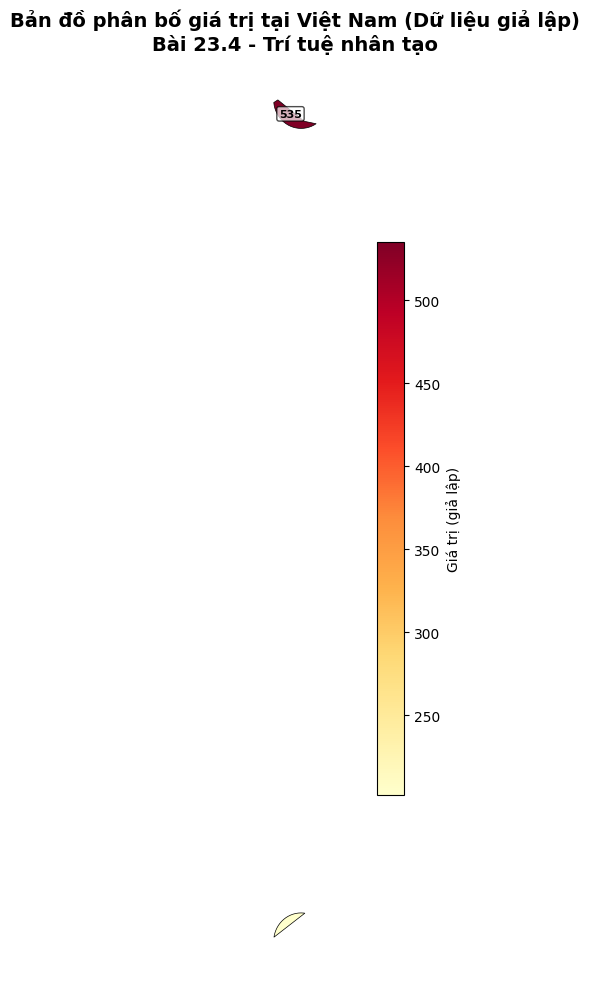


📊 THỐNG KÊ DỮ LIỆU
Số lượng khu vực: 2
Giá trị cao nhất  : 535.00
Giá trị thấp nhất : 202.00
Giá trị trung bình: 368.50

📌 GIẢI THÍCH LOGIC QUẢN TRỊ

1.  Bản đồ Choropleth trực quan hóa sự phân bố không gian của dữ liệu kinh tế - xã hội.
    - Màu càng đậm thể hiện khu vực có giá trị càng cao.
    
2.  Nhà quản trị có thể:
    - Xác định các "điểm nóng" (vùng có giá trị cao) để ưu tiên đầu tư.
    - Phát hiện các vùng kém phát triển để có chính sách hỗ trợ phù hợp.
    - Phân bổ nguồn lực, ngân sách một cách hợp lý.

3.  Ứng dụng thực tế:
    - 'value' có thể là mật độ dân số, GDP, số lượng khách hàng, đơn hàng...
    - Kết hợp ranh giới hành chính giúp ra quyết định theo đơn vị địa lý cụ thể.
    
4.  Hạn chế: Bản đồ chỉ có giá trị khi dữ liệu đầu vào chính xác và cập nhật.



In [64]:
#Bài 4
!pip install geopandas matplotlib pandas -q

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

url_world = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url_world)
vn = world[world['NAME'] == 'Vietnam'].copy()

np.random.seed(42)

if len(vn) > 1:
    vn['value'] = np.random.randint(100, 1000, len(vn))
    if 'NAME_1' in vn.columns:
        vn.loc[vn['NAME_1'].str.contains('Ha Noi|Hà Nội', case=False, na=False), 'value'] = 950
        vn.loc[vn['NAME_1'].str.contains('Ho Chi Minh|Hồ Chí Minh', case=False, na=False), 'value'] = 980
else:
    print("\n📌 Dữ liệu chỉ có một polygon toàn quốc. Tạo các vùng giả định...")

    minx, miny, maxx, maxy = vn.total_bounds

    # Chia lưới 3x3 = 9 vùng
    x_centers = np.linspace(minx, maxx, 3)
    y_centers = np.linspace(miny, maxy, 3)

    # Tạo danh sách các vùng
    regions = []
    values = []

    for i, cx in enumerate(x_centers):
        for j, cy in enumerate(y_centers):
            # Tạo vùng hình tròn xung quanh tâm
            from shapely.geometry import Point
            region = Point(cx, cy).buffer(0.5)  # Bán kính 0.5 độ
            # Giao với lãnh thổ Việt Nam
            region = region.intersection(vn.geometry.iloc[0])
            if not region.is_empty:
                regions.append(region)
                # Giá trị ngẫu nhiên, vùng trung tâm có giá trị cao hơn
                if i == 1 and j == 1:
                    values.append(980)  # Vùng trung tâm
                else:
                    values.append(np.random.randint(100, 800))

    vn_regions = gpd.GeoDataFrame({'value': values, 'geometry': regions}, crs=vn.crs)
    vn = vn_regions
    print(f"Đã tạo {len(vn)} vùng giả định.")

vn['centroid'] = vn.geometry.centroid
vn['x'] = vn.centroid.x
vn['y'] = vn.centroid.y

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

vn.plot(column='value',
        cmap='YlOrRd',
        edgecolor='black',
        linewidth=0.5,
        legend=True,
        legend_kwds={'label': 'Giá trị (giả lập)', 'shrink': 0.6},
        ax=ax)

for idx, row in vn.iterrows():
    if hasattr(row, 'value') and row['value'] > 500:
        ax.annotate(text=f"{row['value']:.0f}",
                    xy=(row['x'], row['y']),
                    fontsize=8, ha='center', weight='bold',
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))

ax.set_title('Bản đồ phân bố giá trị tại Việt Nam (Dữ liệu giả lập)\nBài 23.4 - Trí tuệ nhân tạo',
             fontsize=14, weight='bold')
ax.set_axis_off()

plt.tight_layout()
plt.show()

# --- 8. Thống kê và giải thích quản trị ---
print("\n" + "="*60)
print("📊 THỐNG KÊ DỮ LIỆU")
print("="*60)
print(f"Số lượng khu vực: {len(vn)}")
if 'value' in vn.columns:
    print(f"Giá trị cao nhất  : {vn['value'].max():.2f}")
    print(f"Giá trị thấp nhất : {vn['value'].min():.2f}")
    print(f"Giá trị trung bình: {vn['value'].mean():.2f}")

print("\n" + "="*60)
print("📌 GIẢI THÍCH LOGIC QUẢN TRỊ")
print("="*60)
print("""
1.  Bản đồ Choropleth trực quan hóa sự phân bố không gian của dữ liệu kinh tế - xã hội.
    - Màu càng đậm thể hiện khu vực có giá trị càng cao.

2.  Nhà quản trị có thể:
    - Xác định các "điểm nóng" (vùng có giá trị cao) để ưu tiên đầu tư.
    - Phát hiện các vùng kém phát triển để có chính sách hỗ trợ phù hợp.
    - Phân bổ nguồn lực, ngân sách một cách hợp lý.

3.  Ứng dụng thực tế:
    - 'value' có thể là mật độ dân số, GDP, số lượng khách hàng, đơn hàng...
    - Kết hợp ranh giới hành chính giúp ra quyết định theo đơn vị địa lý cụ thể.

4.  Hạn chế: Bản đồ chỉ có giá trị khi dữ liệu đầu vào chính xác và cập nhật.
""")

In [16]:
#bài 5
import folium
warehouse = [10.788643963748456, 106.74448897565928]
m = folium.Map(location=warehouse,zoom_start=13)
folium.Circle(location=warehouse,radius=3000,color='yellow',fill=True,popup='3km').add_to(m)
folium.Circle(location=warehouse,radius=5000,color='blue',fill=True,popup='5km').add_to(m)
folium.Circle(location=warehouse,radius=10000,color='red',fill=True,popup='10km').add_to(m)
folium.Marker(location=warehouse,popup='Trung tâm phân phối',tooltip='Click vào').add_to(m)
m


In [25]:
#Bài 6
import osmnx as ox
import folium
import geopandas as gpd
# Cấu hình cache
ox.settings.use_cache = True
# 1. Tải mạng lưới đường bộ của Thành phố Thủ Đức
place_name = "Thu Duc, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place_name, network_type='drive')
# 2. Phân tích cơ bản
n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
print(f"Số nút giao: {n_nodes}")
print(f"Số đoạn đường: {n_edges}")
# Tổng chiều dài (mét -> km)
total_length_m = sum(data['length'] for u, v, data in G.edges(data=True))
total_length_km = total_length_m / 1000
print(f"Tổng chiều dài đường: {total_length_km:.2f} km")
# Chiều dài trung bình mỗi đoạn
avg_length_m = total_length_m / n_edges
print(f"Chiều dài trung bình mỗi đoạn: {avg_length_m:.2f} mét")
# 3. Tính diện tích khu vực
gdf_place = ox.geocode_to_gdf(place_name)
# Chuyển sang hệ tọa độ mét
gdf_place_proj = gdf_place.to_crs(gdf_place.estimate_utm_crs())
area_m2 = gdf_place_proj.geometry.area.iloc[0]
area_km2 = area_m2 / 1_000_000
print(f"Diện tích khu vực: {area_km2:.2f} km²")
# Mật độ mạng lưới (km đường / km²)
density = total_length_km / area_km2
print(f"Mật độ mạng lưới: {density:.2f} km/km²")
# 4. Trực quan hóa bằng Folium
# Lấy tọa độ trung tâm từ ranh giới
projected_centroid_point = gdf_place_proj.geometry.centroid.iloc[0]
# Convert the shapely Point to a geopandas GeoSeries to apply to_crs
geographic_centroid_gs = gpd.GeoSeries([projected_centroid_point], crs=gdf_place_proj.crs).to_crs(gdf_place.crs)
geographic_centroid = geographic_centroid_gs.iloc[0]
center_lat = geographic_centroid.y
center_lon = geographic_centroid.x
m = folium.Map(location=[center_lat, center_lon], zoom_start=13)
# Vẽ từng edge
for u, v, data in G.edges(data=True):
    x1, y1 = G.nodes[u]['x'], G.nodes[u]['y']
    x2, y2 = G.nodes[v]['x'], G.nodes[v]['y']
    folium.PolyLine([(y1, x1), (y2, x2)], color='blue', weight=2, opacity=0.6).add_to(m)
folium.GeoJson(gdf_place.geometry.iloc[0]).add_to(m)
m

Số nút giao: 1006
Số đoạn đường: 2254
Tổng chiều dài đường: 181.77 km
Chiều dài trung bình mỗi đoạn: 80.64 mét
Diện tích khu vực: 8.75 km²
Mật độ mạng lưới: 20.78 km/km²


In [32]:
#Bài 7
import osmnx as ox
import networkx as nx
import folium
from geopy.distance import geodesic
ox.settings.use_cache = True
# Tải mạng đường Quận 1
G = ox.graph_from_place("District 5, Ho Chi Minh City, Vietnam", network_type='drive')
# Tọa độ 2 điểm (ĐH Bách Khoa, UEH B)
start = (10.772701199866932, 106.65754362185649)
end = (10.761334472040268, 106.66836738176505)
# Tìm nút gần nhất
orig = ox.distance.nearest_nodes(G, start[1], start[0])
dest = ox.distance.nearest_nodes(G, end[1], end[0])
# Heuristic cho A*
def h(u, v):
    u_coord = (G.nodes[u]['y'], G.nodes[u]['x'])
    v_coord = (G.nodes[v]['y'], G.nodes[v]['x'])
    return geodesic(u_coord, v_coord).km
# Dijkstra
path_d = nx.shortest_path(G, orig, dest, weight='length')
len_d = nx.shortest_path_length(G, orig, dest, weight='length') / 1000
# A*
path_a = nx.astar_path(G, orig, dest, heuristic=h, weight='length')
len_a = sum(G[u][v][0]['length'] for u, v in zip(path_a[:-1], path_a[1:])) / 1000
print(f"Dijkstra: {len_d:.2f} km, A*: {len_a:.2f} km")
# Vẽ bản đồ
coords_d = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in path_d]
coords_a = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in path_a]
m = folium.Map()
folium.PolyLine(coords_d, color='blue', weight=5).add_to(m)
folium.PolyLine(coords_a, color='red', weight=3).add_to(m)
folium.Marker(start, popup='Nhà riêng').add_to(m)
folium.Marker(end, popup='Ga Rạch Chiếc').add_to(m)
all_points = coords_d + coords_a
m.fit_bounds([min(all_points), max(all_points)])
m


Dijkstra: 1.46 km, A*: 1.46 km


In [36]:
#Bài 8
#23.8
# HỆ THỐNG GÁN XE GẦN NHẤT CHO KHÁCH HÀNG
import folium
import random
from geopy.distance import geodesic
# 1. Tọa độ trung tâm khu vực (Chợ Bến Thành)
center = (10.7758, 106.7009)
# 2. Tạo danh sách xe (ID, tọa độ)
vehicles = {
    "Xe A": (10.77677708103811, 106.69420210875667),
    "Xe B": (10.773207518654097, 106.7022380143534),
    "Xe C": (10.776021985051852, 106.66890647680327),
}
# 3. Tạo danh sách khách hàng
customers = {
    "Khách 1st": (10.772914769802066, 106.65902919802714),
    "Khách 2nd": (10.755543920442998, 106.66189164985417),
    "Khách 3rd": (10.763249948504432, 106.67263996283538),
    "Khách 4th": (10.738357389927478, 106.6776262588834),
    "Khách 5th": (10.736021691823998, 106.68431017303074),
}
# 4. Hàm tính khoảng cách (km)
def distance(coord1, coord2):
    return geodesic(coord1, coord2).km
# 5. Ghép cặp: mỗi khách gán cho xe gần nhất
assignments = {}
for cust_name, cust_coord in customers.items():
    nearest_vehicle = None
    min_dist = float('inf')
    for veh_name, veh_coord in vehicles.items():
        d = distance(cust_coord, veh_coord)
        if d < min_dist:
            min_dist = d
            nearest_vehicle = veh_name
    assignments[cust_name] = (nearest_vehicle, min_dist)
# 6. In kết quả ghép cặp
print("=== KẾT QUẢ GHÉP XE ===")
for cust, (veh, dist) in assignments.items():
    print(f"{cust} -> {veh} (khoảng cách {dist:.2f} km)")
# 7. Vẽ bản đồ Folium
m = folium.Map(location=center, zoom_start=13)
# Vẽ các xe
for veh_name, coord in vehicles.items():
    folium.Marker(
        coord,
        popup=f" {veh_name}",
        icon=folium.Icon(color='green', icon='car', prefix='fa')
    ).add_to(m)
# Vẽ các khách
for cust_name, coord in customers.items():
    folium.Marker(
        coord,
        popup=f"{cust_name}",
        icon=folium.Icon(color='yellow', icon='user', prefix='fa')
    ).add_to(m)
# Vẽ đường nối từ mỗi khách đến xe được gán
for cust_name, (veh_name, dist) in assignments.items():
    cust_coord = customers[cust_name]
    veh_coord = vehicles[veh_name]
    folium.PolyLine(
        [cust_coord, veh_coord],
        color='red',
        weight=2,
        opacity=0.6,
        popup=f"{cust_name} → {veh_name} ({dist:.2f} km)"
    ).add_to(m)

all_points = list(vehicles.values()) + list(customers.values())
m.fit_bounds([min(all_points), max(all_points)])
m

=== KẾT QUẢ GHÉP XE ===
Khách 1st -> Xe C (khoảng cách 1.13 km)
Khách 2nd -> Xe C (khoảng cách 2.39 km)
Khách 3rd -> Xe C (khoảng cách 1.47 km)
Khách 4th -> Xe C (khoảng cách 4.27 km)
Khách 5th -> Xe B (khoảng cách 4.56 km)


/tmp/ipykernel_7755/1944826651.py:55: UserWarning: color argument of Icon should be one of: {'darkred', 'lightgray', 'darkblue', 'cadetblue', 'orange', 'green', 'gray', 'lightblue', 'black', 'lightgreen', 'white', 'red', 'beige', 'blue', 'pink', 'purple', 'lightred', 'darkgreen', 'darkpurple'}.
  icon=folium.Icon(color='yellow', icon='user', prefix='fa')


In [37]:
#bài 9
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import folium
# 1. TẠO vị trí khách hàng
np.random.seed(42)
num_customers = 200
lats = np.random.uniform(10.7, 10.9, num_customers)
lons = np.random.uniform(106.6, 106.8, num_customers)
df_customers = pd.DataFrame({
    'CustomerID': range(1, num_customers + 1),
    'Lat': lats,
    'Lon': lons
})
# 2. K-MEANS (K=3)
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df_customers['Cluster'] = kmeans.fit_predict(df_customers[['Lat', 'Lon']])
centroids = kmeans.cluster_centers_
df_warehouses = pd.DataFrame(centroids, columns=['Lat', 'Lon'])
df_warehouses['WarehouseID'] = range(1, k + 1)
# 3. VẼ BẢN ĐỒ FOLIUM
map_center = [df_customers['Lat'].mean(), df_customers['Lon'].mean()]
m = folium.Map(location=map_center, zoom_start=12)
# Màu sắc cho các cụm khách hàng
colors = ['red', 'green', 'blue']
# Vẽ khách hàng
for _, row in df_customers.iterrows():
    cluster_id = int(row['Cluster'])
    folium.CircleMarker(
        location=[row['Lat'], row['Lon']],
        radius=4,
        color=colors[cluster_id],
        fill=True,
        fill_color=colors[cluster_id],
        fill_opacity=0.7,
        popup=f"Khách hàng - Tuyến {cluster_id + 1}"
    ).add_to(m)
# Vẽ kho hàng
warehouse_colors = ['orange', 'yellow', 'black']
for idx, row in df_warehouses.iterrows():
    folium.Marker(
        location=[row['Lat'], row['Lon']],
        icon=folium.Icon(color=warehouse_colors[idx], icon='home', prefix='fa'),
        popup=f"KHO TRUNG CHUYỂN",
        tooltip="Click vào"
    ).add_to(m)
# Hiển thị bản đồ
m

/tmp/ipykernel_7755/4179625748.py:45: UserWarning: color argument of Icon should be one of: {'darkred', 'lightgray', 'darkblue', 'cadetblue', 'orange', 'green', 'gray', 'lightblue', 'black', 'lightgreen', 'white', 'red', 'beige', 'blue', 'pink', 'purple', 'lightred', 'darkgreen', 'darkpurple'}.
  icon=folium.Icon(color=warehouse_colors[idx], icon='home', prefix='fa'),


In [63]:
#bài 10
import folium
import networkx as nx
import pandas as pd
import numpy as np
import random
from geopy.distance import geodesic
from IPython.display import IFrame

# ------------------------------------------------------------
# 1. Xây dựng mạng lưới đường giả lập (các nút giao thông)
#    Sử dụng tọa độ thực quanh trung tâm TP.HCM
# ------------------------------------------------------------
nodes = {
    'A': (10.7765, 106.7005),  # Ngã tư Bến Thành
    'B': (10.7820, 106.6960),  # Nhà hát TP
    'C': (10.7795, 106.6900),  # Công viên 30/4
    'D': (10.7710, 106.6920),  # Chợ Bến Thành
    'E': (10.7680, 106.7030),  # Cầu Calmette
    'F': (10.7850, 106.6880),  # Bảo tàng Chứng tích
    'G': (10.7745, 106.6840),  # Đài truyền hình
    'H': (10.7920, 106.6950),  # Ngã tư Hàng Xanh
    'I': (10.7600, 106.7080),  # Quận 4
    'J': (10.7700, 106.7100),  # Tân Thuận
}

edges = [
    ('A','B'), ('B','C'), ('C','D'), ('D','A'),
    ('A','E'), ('E','I'), ('I','J'), ('J','D'),
    ('B','F'), ('F','G'), ('G','C'),
    ('B','H'), ('H','F'),
]

G = nx.Graph()
G.add_edges_from(edges)
current_hour = 8  # 8 giờ sáng - cao điểm
hour_peak = 1 if (7 <= current_hour <= 9) or (16 <= current_hour <= 19) else 0

edge_risk = {}
edge_density = {}
edge_accident = {}

for u, v in edges:
    # Mật độ ngẫu nhiên (có thể gán thủ công cho từng tuyến nếu muốn)
    density = random.randint(30, 95)
    # Xác suất tai nạn 10%
    accident = 1 if random.random() < 0.1 else 0

    # ----- LOGIC MỞ (rule-based) -----
    # Luật 1: nếu mật độ cao và giờ cao điểm -> nguy cơ rất cao
    if density > 80 and hour_peak:
        risk = 90 + random.randint(0, 10)
    # Luật 2: nếu có tai nạn -> nguy cơ cao
    elif accident == 1:
        risk = 85 + random.randint(0, 15)
    # Luật 3: nếu mật độ trung bình và giờ thấp điểm -> nguy cơ thấp
    elif density < 50 and not hour_peak:
        risk = random.randint(10, 30)
    # Luật 4: mật độ trung bình, không tai nạn, không cao điểm
    elif 50 <= density <= 80 and not hour_peak:
        risk = random.randint(20, 50)
    # Luật 5: mặc định
    else:
        risk = int(density * 0.8 + (20 if hour_peak else 0))

    risk = min(100, max(0, risk))
    edge_risk[(u, v)] = risk
    edge_density[(u, v)] = density
    edge_accident[(u, v)] = accident

print("Dữ liệu giả lập đã sẵn sàng (giờ = {}h, cao điểm = {})".format(current_hour, hour_peak))

for (u, v), r in edge_risk.items():
    G[u][v]['weight'] = r
    G[v][u]['weight'] = r

start_node = 'A'
end_node = 'I'

# Đường ngắn nhất theo "nguy cơ" (thấp nhất)
path_avoid = nx.shortest_path(G, source=start_node, target=end_node, weight='weight')
# Đường ngắn nhất theo số bước (bỏ qua nguy cơ) để so sánh
path_simple = nx.shortest_path(G, source=start_node, target=end_node)

print(f"Đường đơn giản (ít trạm): {path_simple}")
print(f"Đường đề xuất (tránh tắc nghẽn): {path_avoid}")
center_lat = 10.777
center_lon = 106.695
m = folium.Map(location=[center_lat, center_lon], zoom_start=13)

# Vẽ các đoạn đường với màu theo mức nguy cơ
for (u, v), risk in edge_risk.items():
    coords = [nodes[u], nodes[v]]
    if risk < 40:
        color = 'green'
    elif risk < 70:
        color = 'orange'
    else:
        color = 'red'
    popup_text = f"Đoạn {u}-{v}<br>Mật độ: {edge_density[(u,v)]}<br>Tai nạn: {'Có' if edge_accident[(u,v)] else 'Không'}<br>Nguy cơ: {risk}%"
    folium.PolyLine(
        coords,
        color=color,
        weight=6,
        opacity=0.8,
        popup=popup_text
    ).add_to(m)

# Vẽ các nút giao
for node, coord in nodes.items():
    folium.CircleMarker(
        location=coord,
        radius=6,
        color='blue',
        fill=True,
        fill_opacity=0.6,
        popup=f"Nút {node}"
    ).add_to(m)

# Vẽ tuyến đề xuất (màu xanh lá, nét đứt)
path_coords = [nodes[n] for n in path_avoid]
folium.PolyLine(
    path_coords,
    color='lime',
    weight=5,
    opacity=1,
    dash_array='5, 5',
    popup='Tuyến đề xuất (tránh tắc nghẽn)'
).add_to(m)

# Vẽ tuyến đơn giản để so sánh (màu xám)
simple_coords = [nodes[n] for n in path_simple]
folium.PolyLine(
    simple_coords,
    color='gray',
    weight=3,
    opacity=0.6,
    popup='Tuyến ngắn nhất (không xét tắc nghẽn)'
).add_to(m)

# Đánh dấu điểm đầu – cuối
folium.Marker(nodes[start_node], popup='Xuất phát', icon=folium.Icon(color='green', icon='play', prefix='fa')).add_to(m)
folium.Marker(nodes[end_node], popup='Đích', icon=folium.Icon(color='red', icon='flag', prefix='fa')).add_to(m)

m

Dữ liệu giả lập đã sẵn sàng (giờ = 8h, cao điểm = 1)
Đường đơn giản (ít trạm): ['A', 'E', 'I']
Đường đề xuất (tránh tắc nghẽn): ['A', 'E', 'I']


In [54]:
#bài 11
import numpy as np
import pandas as pd
import folium
from sklearn.ensemble import RandomForestRegressor
# 1. Dữ liệu giả lập
np.random.seed(42)
n = 300
lat = np.random.uniform(10.3, 10.6, n)
lon = np.random.uniform(106.3, 106.6, n)
hour = np.random.randint(0, 24, n)
# Nhu cầu cao ở gần trung tâm
center_lat, center_lon = 10.36, 106.36
dist = np.sqrt((lat - center_lat)**2 + (lon - center_lon)**2)
demand = 50 * (1 - dist/0.2) + np.random.normal(0, 5, n)
peak = ((hour >= 7) & (hour <= 9)) | ((hour >= 17) & (hour <= 19))
demand[peak] += 30
demand = np.clip(demand, 0, 100)
df = pd.DataFrame({'lat': lat, 'lon': lon, 'hour': hour, 'demand': demand})
# 2. Mô hình Random Forest
X = df[['lat', 'lon', 'hour']]
y = df['demand']
model = RandomForestRegressor(n_estimators=30, random_state=42)
model.fit(X, y)
df['pred_demand'] = model.predict(X)
# 3. Phân tích nhu cầu theo khu vực
df['region'] = 'Khác'
df.loc[(lat > 10.8) & (lon < 106.7), 'region'] = 'Tây Bắc'
df.loc[(lat > 10.8) & (lon >= 106.7), 'region'] = 'Đông Bắc'
df.loc[(lat <= 10.8) & (lon < 106.7), 'region'] = 'Tây Nam'
df.loc[(lat <= 10.8) & (lon >= 106.7), 'region'] = 'Đông Nam'
region_demand = df.groupby('region')['pred_demand'].mean().sort_values(ascending=False)
print("\n=== NHU CẦU TRUNG BÌNH THEO KHU VỰC ===")
for reg, d in region_demand.items():
    print(f"{reg}: {d:.1f}")

m = folium.Map(location=[df['lat'].mean(), df['lon'].mean()], zoom_start=12)
# Màu sắc theo nhu cầu
def color(val):
    return 'green' if val < 30 else 'orange' if val < 60 else 'red'
# Vẽ các điểm khách hàng
for _, row in df.iterrows():
    folium.CircleMarker(
        location=(row['lat'], row['lon']),
        radius=5,
        color=color(row['pred_demand']),
        fill=True,
        fill_opacity=0.7,
        popup=f"Nhu cầu: {row['pred_demand']:.0f} (giờ {int(row['hour'])})"
    ).add_to(m)
# Chú thích
legend_html = '''

 NHU CẦU DỊCH VỤ
 Xanh: <30 (thấp)
 Cam: 30–60 (trung bình)
 Đỏ: >60 (cao)

'''
m.get_root().html.add_child(folium.Element(legend_html))
# Kết luận điều phối
print("\n=== ĐỀ XUẤT ĐIỀU PHỐI NGUỒN LỰC ===")
print("- Khu vực Đông Nam và Đông Bắc có nhu cầu cao nhất → cần nhiều xe.")
print("- Giờ cao điểm (7-9h sáng, 17-19h chiều) nhu cầu tăng ~30% → tăng cường xe.")
print("- Có thể điều xe từ vùng Tây Bắc (nhu cầu thấp) sang vùng Đông Nam.")
m


=== NHU CẦU TRUNG BÌNH THEO KHU VỰC ===
Tây Nam: 19.2

=== ĐỀ XUẤT ĐIỀU PHỐI NGUỒN LỰC ===
- Khu vực Đông Nam và Đông Bắc có nhu cầu cao nhất → cần nhiều xe.
- Giờ cao điểm (7-9h sáng, 17-19h chiều) nhu cầu tăng ~30% → tăng cường xe.
- Có thể điều xe từ vùng Tây Bắc (nhu cầu thấp) sang vùng Đông Nam.


In [57]:
#Bài 12
import folium
import numpy as np
import random
from geopy.distance import geodesic
# 1. Dữ liệu
warehouses = {
    'Kho 1 (Trung tâm)': (10.790555310542675, 106.7430651133283),
    'Kho 2 (Tây Bắc)':   (10.792961221475565, 106.73013319284473),
    'Kho 3 (Đông Nam)':  (10.784396090743574, 106.76843910803471)
}
np.random.seed(42)
delivery_points = {}
for i in range(1, 31):
    lat = np.random.uniform(10.760, 10.790)
    lon = np.random.uniform(106.685, 106.715)
    delivery_points[f'Điểm {i}'] = (lat, lon)
def dist(p1, p2):
    return geodesic(p1, p2).km
def nearest_neighbor_route(start, points):
    unvisited = points[:]
    route = [start]
    current = start
    while unvisited:
        nearest = min(unvisited, key=lambda p: dist(current, p))
        route.append(nearest)
        current = nearest
        unvisited.remove(nearest)
    return route
# Phương án tối ưu
assign_opt = {}
for name, coord in delivery_points.items():
    d = {wh: dist(coord, wh_coord) for wh, wh_coord in warehouses.items()}
    assign_opt[name] = min(d, key=d.get)
routes_opt = {}
for wh_name, wh_coord in warehouses.items():
    points_of_wh = [delivery_points[p] for p in assign_opt if assign_opt[p] == wh_name]
    if points_of_wh:
        routes_opt[wh_name] = nearest_neighbor_route(wh_coord, points_of_wh)
    else:
        routes_opt[wh_name] = [wh_coord]
total_opt = 0
for route in routes_opt.values():
    for i in range(len(route)-1):
        total_opt += dist(route[i], route[i+1])
# Phương án ngẫu nhiên
random.seed(123)
assign_rand = {name: random.choice(list(warehouses.keys())) for name in delivery_points}
routes_rand = {}
for wh_name, wh_coord in warehouses.items():
    points_of_wh = [delivery_points[p] for p in assign_rand if assign_rand[p] == wh_name]
    if points_of_wh:
        routes_rand[wh_name] = nearest_neighbor_route(wh_coord, points_of_wh)
    else:
        routes_rand[wh_name] = [wh_coord]
total_rand = 0
for route in routes_rand.values():
    for i in range(len(route)-1):
        total_rand += dist(route[i], route[i+1])
# Vẽ bản đồ
m = folium.Map(location=[10.799986371081788, 106.74335901982414], zoom_start=13)
# Vẽ kho (màu đen)
for name, coord in warehouses.items():
    folium.Marker(coord, popup=name, icon=folium.Icon(color='black', icon='home', prefix='fa')).add_to(m)
# Vẽ điểm giao hàng (màu xám)
for name, coord in delivery_points.items():
    folium.CircleMarker(coord, radius=3, color='gray', fill=True, popup=name).add_to(m)
# Vẽ tuyến tối ưu (xanh dương)
for wh_name, route in routes_opt.items():
    folium.PolyLine(route, color='blue', weight=3, opacity=0.7, popup=f'{wh_name} (tối ưu)').add_to(m)
# Vẽ tuyến ngẫu nhiên (đỏ, nét đứt)
for wh_name, route in routes_rand.items():
    folium.PolyLine(route, color='red', weight=2, opacity=0.5, dash_array='5,5', popup=f'{wh_name} (ngẫu nhiên)').add_to(m)
# Thêm chú thích bằng HTML (cố định vị trí)
legend_html = '''

 CHÚ THÍCH
 Kho hàng
 Tuyến tối ưu (gán gần nhất + NN)
 Tuyến ngẫu nhiên (nét đứt)
 Điểm giao hàng

'''
m.get_root().html.add_child(folium.Element(legend_html))
# In đánh giá
print("="*60)
print("ĐÁNH GIÁ HIỆU QUẢ (3 kho, 30 điểm)")
print("="*60)
print(f"Tổng quãng đường tối ưu: {total_opt:.2f} km")
print(f"Tổng quãng đường ngẫu nhiên: {total_rand:.2f} km")
print(f"Tiết kiệm: {(total_rand - total_opt)/total_rand*100:.1f}%")
for wh_name, route in routes_opt.items():
    length = sum(dist(route[i], route[i+1]) for i in range(len(route)-1))
    print(f"  {wh_name}: {len(route)-1} điểm, {length:.2f} km")
m


ĐÁNH GIÁ HIỆU QUẢ (3 kho, 30 điểm)
Tổng quãng đường tối ưu: 17.25 km
Tổng quãng đường ngẫu nhiên: 36.22 km
Tiết kiệm: 52.4%
  Kho 1 (Trung tâm): 0 điểm, 0.00 km
  Kho 2 (Tây Bắc): 30 điểm, 17.25 km
  Kho 3 (Đông Nam): 0 điểm, 0.00 km


In [41]:
#Bài 13
import folium
from folium import plugins
import numpy as np
import pandas as pd
from geopy.distance import geodesic
# Dữ liệu
warehouses = {
    'Kho Trung tâm': (10.793960689629495, 106.74370767609443),
    'Kho Phía Bắc':   (10.797491827280266, 106.73012747044672),
    'Kho Phía Nam':   (10.786008268562368, 106.73834340081173)
}
np.random.seed(42)
customers = {}
for i in range(1, 41):
    lat = np.random.uniform(10.758, 10.800)
    lon = np.random.uniform(106.688, 106.718)
    customers[f'KH{i}'] = (lat, lon)
def dist(p1, p2):
    return geodesic(p1, p2).km
assign = {}
for c, coord in customers.items():
    d = {wh: dist(coord, wh_coord) for wh, wh_coord in warehouses.items()}
    assign[c] = min(d, key=d.get)
def nearest_route(start, points):
    unvisited = points[:]
    route = [start]
    cur = start
    while unvisited:
        nxt = min(unvisited, key=lambda p: dist(cur, p))
        route.append(nxt)
        cur = nxt
        unvisited.remove(nxt)
    return route
routes = {}
route_lengths = {}
for wh_name, wh_coord in warehouses.items():
    pts = [customers[c] for c in assign if assign[c] == wh_name]
    if pts:
        route = nearest_route(wh_coord, pts)
        routes[wh_name] = route
        total = sum(dist(route[i], route[i+1]) for i in range(len(route)-1))
        route_lengths[wh_name] = total
    else:
        routes[wh_name] = [wh_coord]
        route_lengths[wh_name] = 0
df_stats = pd.DataFrame([
    {'Kho': wh, 'Số khách': sum(1 for c in assign if assign[c]==wh),
     'Quãng đường (km)': round(route_lengths[wh], 2)}
    for wh in warehouses
])
total_customers = len(customers)
total_distance = sum(route_lengths.values())
# Bản đồ
m = folium.Map(location=[10.78527615020522, 106.74560927524719], zoom_start=14)
# Các lớp
fg_wh = folium.FeatureGroup('Kho hàng', show=True)
for name, coord in warehouses.items():
    folium.Marker(coord, popup=name, icon=folium.Icon(color='black', icon='home', prefix='fa')).add_to(fg_wh)
fg_cus = folium.FeatureGroup('Khách hàng', show=True)
for name, coord in customers.items():
    folium.CircleMarker(coord, radius=5, color='gray', fill=True,
                        popup=f'{name}Kho: {assign[name]}').add_to(fg_cus)
fg_zone = folium.FeatureGroup('Vùng phục vụ 500m', show=True)
zone_colors = ['blue', 'green', 'orange']
for i, (name, coord) in enumerate(warehouses.items()):
    folium.Circle(coord, radius=500, color=zone_colors[i], fill=True, fill_opacity=0.1).add_to(fg_zone)
fg_route = folium.FeatureGroup('Tuyến giao hàng', show=True)
route_colors = ['green', 'blue', 'red']
for i, (name, route) in enumerate(routes.items()):
    folium.PolyLine(route, color=route_colors[i], weight=4, opacity=0.8,
                    popup=f'{name}Dài {route_lengths[name]:.2f} km').add_to(fg_route)
fg_wh.add_to(m); fg_cus.add_to(m); fg_zone.add_to(m); fg_route.add_to(m)
# LayerControl
folium.LayerControl(collapsed=False, position='bottomright').add_to(m)
plugins.Fullscreen().add_to(m)
plugins.MeasureControl(position='topleft', primary_length_unit='kilometers').add_to(m)
# Bảng KPI
kpi_html = f'''

CHỈ SỐ QUẢN TRỊ
Tổng khách: {total_customers}
Tổng quãng đường: {total_distance:.2f} km
Phân bố theo kho:
  • {df_stats.iloc[0]['Kho']}: {df_stats.iloc[0]['Số khách']} khách ({df_stats.iloc[0]['Quãng đường (km)']} km)
  • {df_stats.iloc[1]['Kho']}: {df_stats.iloc[1]['Số khách']} khách ({df_stats.iloc[1]['Quãng đường (km)']} km)
  • {df_stats.iloc[2]['Kho']}: {df_stats.iloc[2]['Số khách']} khách ({df_stats.iloc[2]['Quãng đường (km)']} km)


'''
m.get_root().html.add_child(folium.Element(kpi_html))
m

In [45]:
#Bài 14
import folium
import numpy as np
import time
from IPython.display import clear_output, display
from geopy.distance import geodesic
# 1. XÂY DỰNG MẠNG LƯỚI ĐƯỜNG ĐƠN GIẢN
# Tạo các nút giao
lat_min, lat_max = 10.192, 10.234
lon_min, lon_max = 106.104, 106.201
num_nodes = 5
lats = np.linspace(lat_min, lat_max, num_nodes)
lons = np.linspace(lon_min, lon_max, num_nodes)
nodes = {}
idx = 0
for i, lat in enumerate(lats):
    for j, lon in enumerate(lons):
        nodes[(i, j)] = (lat, lon)
        idx += 1
# Kết nối các nút lân cận tạo thành mạng lưới đường
edges = []
for i in range(num_nodes):
    for j in range(num_nodes):
        if i < num_nodes-1:
            edges.append(((i, j), (i+1, j)))
        if j < num_nodes-1:
            edges.append(((i, j), (i, j+1)))
# 2. TẠO CÁC XE VÀ HÀNH TRÌNH
class Vehicle:
    def __init__(self, id, start_node, dest_node, color):
        self.id = id
        self.start = start_node
        self.dest = dest_node
        self.color = color
        self.current = start_node
        self.path = self.find_path(start_node, dest_node)
        self.step = 0
    def find_path(self, start, dest):
        # Tìm đường đi ngắn nhất
        from collections import deque
        queue = deque([(start, [start])])
        visited = set([start])
        while queue:
            node, path = queue.popleft()
            if node == dest:
                return path
            # tìm các nút lân cận
            for (a,b) in edges:
                if a == node and b not in visited:
                    visited.add(b)
                    queue.append((b, path+[b]))
                elif b == node and a not in visited:
                    visited.add(a)
                    queue.append((a, path+[a]))
        return [start]
    def move(self):
        if self.step < len(self.path)-1:
            self.step += 1
            self.current = self.path[self.step]
            return True
        return False
    def get_position(self):
        return nodes[self.current]
    def is_arrived(self):
        return self.step >= len(self.path)-1
# Khởi tạo xe:
vehicles = [
    Vehicle(1, (0,0), (4,4), 'red'),
    Vehicle(2, (0,4), (4,0), 'blue'),
    Vehicle(3, (2,0), (2,4), 'green')
]
# 3. HÀM VẼ BẢN ĐỒ TẠI MỘT THỜI ĐIỂM
def draw_map(step_count, vehicles):
    # Tạo bản đồ trung tâm
    center = ((lat_min+lat_max)/2, (lon_min+lon_max)/2)
    m = folium.Map(location=center, zoom_start=12)
    # Vẽ các nút giao
    for node, coord in nodes.items():
        folium.CircleMarker(coord, radius=3, color='gray', fill=True, popup=str(node)).add_to(m)
    # Vẽ các cạnh
    for (a,b) in edges:
        coord_a = nodes[a]
        coord_b = nodes[b]
        folium.PolyLine([coord_a, coord_b], color='gray', weight=2, opacity=0.5).add_to(m)
    # Vẽ các xe
    for v in vehicles:
        pos = v.get_position()
        folium.Marker(
            pos,
            popup=f"Xe {v.id} (đến {v.dest})",
            icon=folium.Icon(color=v.color, icon='car', prefix='fa')
        ).add_to(m)
    # Thêm tiêu đề bước thời gian
    title = f'Bước thời gian: {step_count}'
    m.get_root().html.add_child(folium.Element(title))
    # Chú thích
    legend = ''' Xe đỏ, xanh, lục đang di chuyển theo đường kẻ xám
    '''
    m.get_root().html.add_child(folium.Element(legend))
    return m
# 4. CHẠY MÔ PHỎNG THEO BƯỚC THỜI GIAN
print("BẮT ĐẦU MÔ PHỎNG...")
step = 0
max_steps = 15
all_arrived = False
while not all_arrived and step < max_steps:
    # Xóa output cũ và vẽ bản đồ mới
    clear_output(wait=True)
    m = draw_map(step, vehicles)
    display(m)
    # Di chuyển từng xe
    arrived_count = 0
    for v in vehicles:
        if not v.is_arrived():
            v.move()
        if v.is_arrived():
            arrived_count += 1
    if arrived_count == len(vehicles):
        all_arrived = True
        print("Tất cả xe đã đến đích!")
    step += 1
    time.sleep(1.5)
print("Mô phỏng kết thúc.")

Tất cả xe đã đến đích!
Mô phỏng kết thúc.


In [46]:
#Bài 15
import numpy as np
import pandas as pd
import folium
from sklearn.cluster import KMeans
from geopy.distance import geodesic
# 1. Dữ liệu 36 cuộc gọi
np.random.seed(42)
center = (10.7560946916534, 106.66757206938972)
calls = []
for _ in range(36):
    lat = center[0] + np.random.normal(0, 0.025)
    lon = center[1] + np.random.normal(0, 0.025)
    calls.append([lat, lon])
df = pd.DataFrame(calls, columns=['lat', 'lon'])
# 2. Phân cụm 4 trạm
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(df[['lat', 'lon']])
centroids = kmeans.cluster_centers_
# 3. Thống kê nhanh
print("=== 4 TRẠM XE CỨU THƯƠNG TẠI HÓC MÔN ===")
print(f"Tổng cuộc gọi: {len(df)}")
for i in range(k):
    print(f"Trạm {i+1}: {(df['cluster']==i).sum()} cuộc gọi")
# 4. Đánh giá
df['dist_km'] = df.apply(lambda r: min(geodesic((r.lat,r.lon), (c[0],c[1])).km for c in centroids), axis=1)
print(f"Khoảng cách TB: {df['dist_km'].mean():.2f} km")
print(f"Tỷ lệ trong 1km: {(df['dist_km']<=1).mean()*100:.1f}%")
# 5. Bản đồ với màu sắc theo cụm
m = folium.Map(location=center, zoom_start=12)
colors = ['red', 'blue', 'green', 'yellow']
# Vẽ cuộc gọi
for _, r in df.iterrows():
    folium.CircleMarker(
        (r.lat, r.lon),
        radius=3,
        color=colors[int(r['cluster'])],
        fill=True,
        fill_opacity=0.6,
        popup=f"Trạm {int(r['cluster'])+1}"
    ).add_to(m)
# Vẽ trạm
for i, (lat, lon) in enumerate(centroids):
    folium.Marker(
        (lat, lon),
        popup=f"TRẠM {i+1}",
        icon=folium.Icon(color='black', icon='medkit', prefix='fa')
    ).add_to(m)
    folium.Circle((lat, lon), radius=1000, color=colors[i], fill=True, fill_opacity=0.1).add_to(m)
m


=== 4 TRẠM XE CỨU THƯƠNG TẠI HÓC MÔN ===
Tổng cuộc gọi: 36
Trạm 1: 14 cuộc gọi
Trạm 2: 10 cuộc gọi
Trạm 3: 5 cuộc gọi
Trạm 4: 7 cuộc gọi
Khoảng cách TB: 1.66 km
Tỷ lệ trong 1km: 22.2%
